During the concept phase, we defined the following metric:
$$ f(G) = \frac{max\{ 0, min\{ d_1, d_2, ... d_n\}-1 \}\hat{d_n}}{max\{ 1, max\{d_1, d_2, ..., d_n \} -1\}(n-1)}$$

However, after reviewing the task again, we discovered we also had to adress the 'strength' of an attack. Unfortunately, this definition doesn't take into account this factor, but we can adjust it by slightly redefining the current definition. Our urrent metric can describe how resilient is our network to the loss of one vertex. We can extend this metric by adding parameter k, that will tell us how resilient is Graph to a k vertices removal. We therefore have:

$$ f(G, k) = \frac{max\{ 0, min\{ d_1, d_2, ... d_n\}-k \}\hat{d_n}}{max\{ 1, max\{d_1, d_2, ..., d_n \} -k\}(n-1)}$$

In [1]:
import matplotlib.pyplot as plt
import scipy.stats as sc
import numpy as np
import networkx as nx

In [2]:
def measure(G, k=0):
    dG = [d for _, d in G.degree()]

    x = max(np.min(dG)-k, 0)
    y = max(np.max(dG)-k, 1)
    d_av = np.mean(dG)
    return x * d_av / (y * (G.number_of_nodes()-1))

### Dense and sparse network

Our dense network shows connections in the brain. Each vertex represents a brain region, and an edge means that there are nerve fibers connecting those two regions. Average density is $\approx 0.69$, which is a relatively big figure.


Our sparse networks shows power grid in United States. Vertices represents power stations, and edges are direct connections between those stations. Average density is about: $5.4 \cdot 10^{-4}$, which is a relatively low number.

### Dense example

In [3]:
from scipy.io import mmread

path1 = "C:/Users/Kacper/Desktop/TUe courses/Complex Networks/ProjectModule2/brock200-1.mtx"

A = mmread(path1)
brain = nx.from_scipy_sparse_array(A)
print(brain)
K = np.linspace(1, 50, 5).astype(int)
for k in K:
    print(f'Attack strength of {k}: {round(measure(brain, k), 3)}')

Graph with 200 nodes and 14834 edges
Attack strength of 1: 0.586
Attack strength of 13: 0.574
Attack strength of 25: 0.559
Attack strength of 37: 0.542
Attack strength of 50: 0.519


C:\Users\Kacper\AppData\Local\Temp\ipykernel_21252\969796125.py:5: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  A = mmread(path1)


We see, that as we increase the attack strength, we get smaller values. This is expected behaviour because of our definition that measures the relationship between the min and max of a degree. Even at k = 50, we get nonzero values, which means the network seems to be robust.

### Sparse example

In [4]:
path2 = "C:/Users/Kacper/Desktop/TUe courses/Complex Networks/ProjectModule2/inf-power.mtx"
B = mmread(path2)
power_grid = nx.from_scipy_sparse_array(B)

K = np.linspace(1, 50, 5)
print(f'Graph is connected: {nx.is_connected(power_grid)}')
print(f'Attack of a strength {1}: {measure(power_grid, 1)}')


Graph is connected: True
Attack of a strength 1: 0.0


C:\Users\Kacper\AppData\Local\Temp\ipykernel_21252\406739832.py:2: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  B = mmread(path2)


In this case, we got a zero. This means that the networks is not resilient to attacks of any level, and if we delete just one vertex there is a chance that at least one of the vertices won't be connected to others. This is something we expected, since the density is very small.

### Erdos Renyi Graph
Now we will test it on a Erdos Renyi Graphs with a connection probability $p=\frac{\lambda}{n}$. We will take three different $\lambda$ values, and see how the behaviour of our function changes as we increase the attack strength and also increase the number of vertices.

In [5]:
n_of_steps = 50
repeat = 10
N = np.linspace(100, 1000, n_of_steps).astype(int)

def measure_ER(lam, k):
    results_vector = np.empty(n_of_steps)
    for num, n in enumerate(N):
        p = lam/n
        n_res = np.empty(repeat)
        for r in range(repeat):
            G = nx.fast_gnp_random_graph(n, p)
            while not nx.is_connected(G):
                G = nx.fast_gnp_random_graph(n, p)
            n_res[r] = measure(G, k)
        results_vector[num] = np.mean(n_res)
        #print(num)
    return results_vector

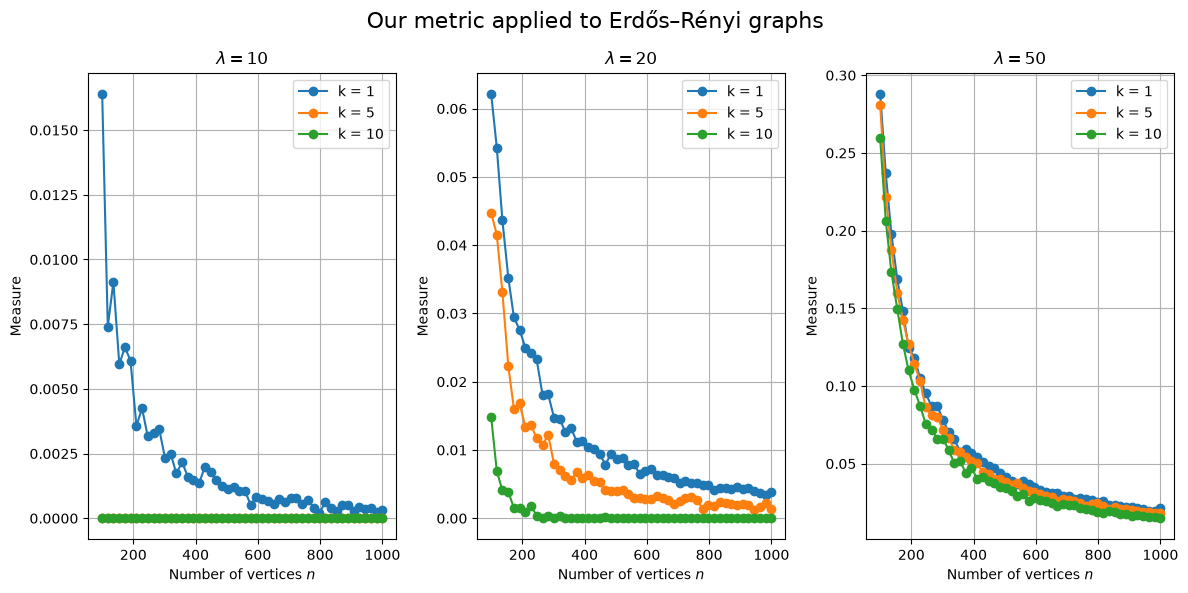

In [6]:
K = [1, 5, 10]

fig, axs = plt.subplots(1, 3, figsize=(12, 6))

for k in K:
    y1 = measure_ER(10, k)
    y2 = measure_ER(20, k)
    y3 = measure_ER(50, k)

    axs[0].plot(N, y1, marker='o', label=f'k = {k}')
    axs[1].plot(N, y2, marker='o', label=f'k = {k}')
    axs[2].plot(N, y3, marker='o', label=f'k = {k}')

# Main title
fig.suptitle('Our metric applied to Erdős–Rényi graphs', fontsize=16)
axs[0].set_title(r'$\lambda = 10$')
axs[1].set_title(r'$\lambda = 20$')
axs[2].set_title(r'$\lambda = 50$')

for i in range(3):
    axs[i].set_xlabel('Number of vertices $n$')
    axs[i].set_ylabel('Measure')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

We see, that as the number of vertices increases, the values of our metric approach zero. This can be explained intuitevely. Since the number of vertices increases, the chance that the degree of at least one of them will be either small or large increases. Since we use both min and max functios in our definition, we expect that the difference between them will increase, which will result in smaller values.

What interesting is, that $\lambda$ parameter also has an impact on the function and its behaviour for different k values.

### Thoughts on our metric

At first, we had to slightly change our metric by adding the k parameter which represants 'attack size'. Our current definition describes the 'worst case scenario', which is the situation when we delete the neighbour of a vertex with the smallest degree, even if such situation has a very low probability. We could change it by adding for example probability factor that we choose this exact vertex to be deleted.